# Lamina Tubulin Fit Workflow

Clean workflow for loading a calibrated HDF5 file, preparing aligned summed decays, generating per-pixel fit maps, and visualizing the lifetime result.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SRC = str(ROOT / "src")
if SRC in sys.path:
    sys.path.remove(SRC)
sys.path.insert(0, SRC)
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists():
    MCS_FILE_SRC = str(MCS_FILE_SRC)
    if MCS_FILE_SRC in sys.path:
        sys.path.remove(MCS_FILE_SRC)
    sys.path.insert(0, MCS_FILE_SRC)

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_mcs_file.alignment as alignment_module
import brighteyes_flim.graph_tools as graph
alignment_module = importlib.reload(alignment_module)
graph = importlib.reload(graph)

from brighteyes_mcs_file.alignment import Alignment
from brighteyes_mcs_file import show_h5_structure_html, sum_channel_applying_shifts


In [2]:
DATA_CALIBRATE = '/mnt/DATA/Mixed Data/lamina+tubulin/data-10-04-2024-19-27-47_calib.h5'


## Inspect Calibration File


In [3]:
#show_h5_structure_html(DATA_CALIBRATE)


## Load Data And Metadata


In [4]:
with h5py.File(DATA_CALIBRATE, "r") as hf:
    calibration = hf["calibration/data"]
    configuration = hf["configurationGUI"]

    laser_freq_mhz = float(calibration.attrs["laser_freq_in_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_in_ns"])
    nbin = int(configuration.attrs["timebin_per_pixel"])
    pixel_size_x_um = float(configuration.attrs["range_x"]) / float(configuration.attrs["nx"])
    pxdwelltime = float(configuration.attrs["time_resolution"]) * nbin

    data_input = hf["data"][:]
    channel_skew = calibration["channel_skew"][:]
    irf_common_delay_realigned = calibration["irf_common_delay_realigned"][:]

t = np.arange(nbin, dtype=float) * laser_period_ns / nbin

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print("data_input:", data_input.shape)
print("irf_common_delay_realigned:", irf_common_delay_realigned.shape)
print("pixel_size_x_um:", pixel_size_x_um)
print("pxdwelltime:", pxdwelltime)


Using calibrated laser timing: 41.4800 MHz (24.1080 ns)
data_input: (1, 1, 1250, 1250, 81, 25)
irf_common_delay_realigned: (81, 25)
pixel_size_x_um: 0.04
pxdwelltime: 162.0


## Sum Channels With The Calibration Shifts


In [5]:
irf_for_fit = np.asarray(irf_common_delay_realigned, dtype=float)


In [6]:
data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed = sum_channel_applying_shifts(irf_for_fit, channel_skew, axis=())


if True:   #This filter on IRF has been activated for being coherent with the analysis in the paper of S2ISM
    irf_summed = Alignment.clean_irf_stack( 
        irf_summed, 
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_rev = sum_channel_applying_shifts(
    data_input,
    channel_skew,
    axis=(),
    reverse_shifts=False,
)[0, 0, ...]
irf_summed_rev = sum_channel_applying_shifts(
    irf_for_fit,
    channel_skew,
    axis=(),
    reverse_shifts=False,
)

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment = np.sum(irf_for_fit, axis=-1)

print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)


Summing shifted histograms:   0%|          | 0/1562500 [00:00<?, ?it/s]

Summing shifted histograms:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histograms:   0%|          | 0/1562500 [00:00<?, ?it/s]

Summing shifted histograms:   0%|          | 0/1 [00:00<?, ?it/s]

data_summed: (1250, 1250, 81)
irf_summed: (81,)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

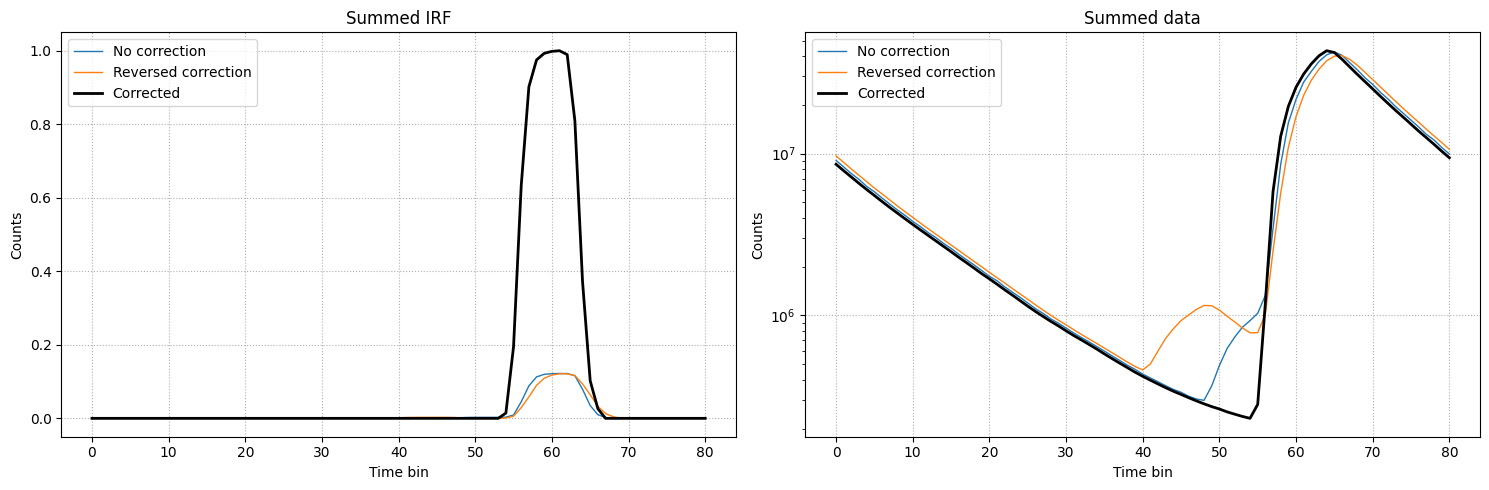

In [7]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)


## Check One Pixel Fit


{'C': np.float64(1.0),
 'dT': np.float64(-0.052478228291533924),
 'tau': np.float64(2.9669750807306734)}

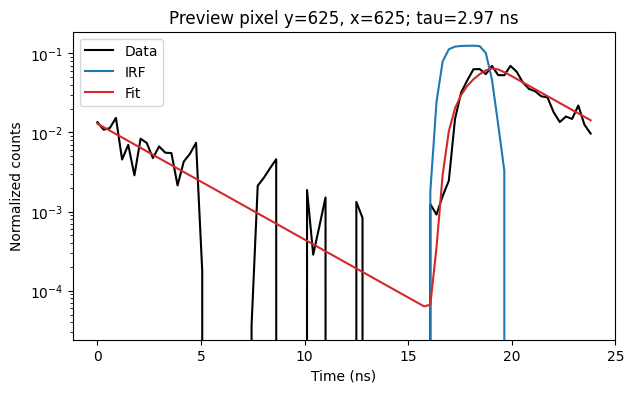

In [8]:
preview_y = data_summed.shape[0] // 2
preview_x = data_summed.shape[1] // 2
preview_hist = data_summed[preview_y, preview_x, :]

preview_result, preview_cov = Alignment.perform_fit_data(
    t=t,
    data=preview_hist,
    irf=irf_summed,
    period=laser_period_ns,
    initial_tau=None,
    initial_dT=None,
    initial_C=None,
    mode='model_shift',
    fit_type='likelihood',
    force_C_normalized=True,
)

fit_preview = Alignment.fit_model_data(
    t,
    preview_result["C"],
    preview_result["dT"],
    preview_result["tau"],
    irf=irf_summed,
    period=laser_period_ns,
    mode='model_shift',
)

fit_preview = Alignment.to_numpy_1d(fit_preview, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, preview_hist / preview_hist.sum(), label="Data", color="black")
ax.plot(t, irf_summed / irf_summed.sum(), label="IRF", color="tab:blue")
ax.plot(t, fit_preview / fit_preview.sum(), label="Fit", color="tab:red")
ax.set_yscale("log")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Normalized counts")
ax.set_title(f"Preview pixel y={preview_y}, x={preview_x}; tau={preview_result['tau']:.2f} ns")
ax.legend()
preview_result


## Generate Fit Maps


In [9]:
if not hasattr(Alignment, "generate_fit_maps"):
    raise RuntimeError(
        "The notebook kernel still has an old brighteyes_mcs_file.alignment module loaded. "
        "Rerun the first import cell, or restart the kernel and run from the top."
    )

fit_maps = Alignment.generate_fit_maps(
    data=data_summed,
    irf=irf_summed,
    t=t,
    period=laser_period_ns,
    initial_tau=None,
    initial_dT=None,
    initial_C=None,
    mode='model_shift',
    fit_type='likelihood',
    force_C_normalized=True,
    n_jobs=-1,
)

fit_stack, fit_stack_names = Alignment.fit_maps_to_stack(fit_maps)
print("fit_stack shape:", fit_stack.shape)
print("fit_stack axis 0:", fit_stack_names)


Fitting pixels:   0%|          | 0/1562500 [00:00<?, ?it/s]

fit_stack shape: (6, 1250, 1250)
fit_stack axis 0: ['C', 'dT', 'tau', 'C_err', 'dT_err', 'tau_err']


## Visualize Lifetime Fit


In [10]:
tau = fit_maps["tau"]
intensity = data_summed.sum(axis=-1)

thresholded_tau, thresholded_intensity, lifetime_mask = graph.threshold_lifetime_map(
    tau,
    intensity=intensity,
    threshold=0.05,
)

print("finite tau pixels:", np.count_nonzero(np.isfinite(tau)))
print("thresholded pixels:", thresholded_tau.size)


finite tau pixels: 1562500
thresholded pixels: 1536787


/home/mdonato/.local/share/mamba/envs/venv-3.12/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

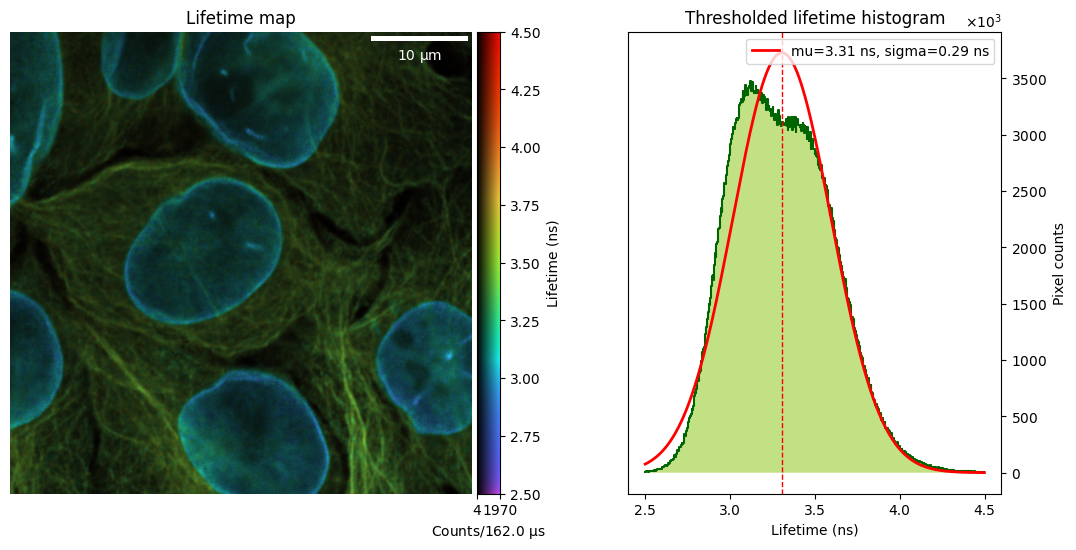

In [11]:
graph.plot_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[2.5, 4.5],
    crop=30,
    threshold=0.05,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/mdonato/.local/share/mamba/envs/venv-3.12/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

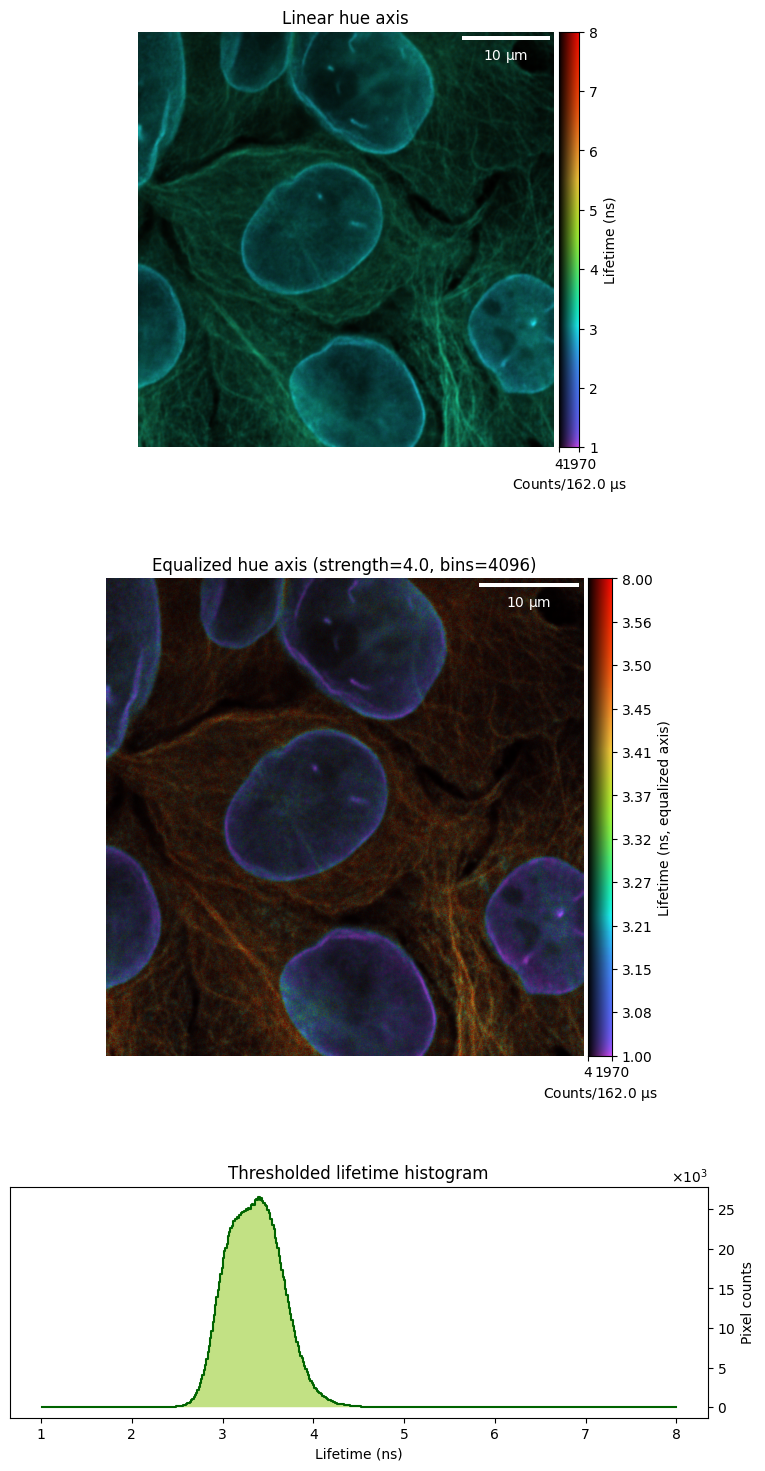

In [13]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 8.0],
    crop=30,
    threshold=0.05,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)
